# 01 — The dataset, and what hashing it revealed

1 506 MRI files: a labelled pool of 100 (normal / cancer) and an unlabelled pool of 1 406.
The plan was to embed them with a frozen ResNet50, cluster the embeddings, and turn the
clusters into pseudo-labels for a semi-supervised model.

This notebook starts one step earlier, with a question the original pipeline never asked.

**Are these files as many images as the folder listing suggests?**

In [1]:
import numpy as np
import pandas as pd

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

## 1. Identity comes from content, not from the path

The first version of this pipeline identified an image by an MD5 of its **file path**. Two
copies of one scan filed in two folders therefore received two different identifiers — and
the guard meant to keep the labelled images out of the unlabelled pool, an exclusion on the
folder name, had nothing to catch them with.

Here an image is what it contains.

In [2]:
from mri_semisupervised.config import LABELLED_DIR, UNLABELLED_DIR
from mri_semisupervised.data.manifest import apply_duplicate_rules, build_manifest, summarise

manifest = apply_duplicate_rules(build_manifest(LABELLED_DIR, UNLABELLED_DIR))
facts = summarise(manifest)
for key, value in facts.items():
    print(f"{key:34} {value}")

files                              1506
unreadable_files                   0
distinct_images                    1410
labelled_files                     100
evaluation_images                  99
repeated_labelled_copies_dropped   1
unlabelled_files                   1406
labelled_also_in_unlabelled        31
labelled_also_in_unlabelled_files  32
leaked_by_class                    {'normal': 23, 'cancer': 8}
evaluation_class_balance           {'cancer': 50, 'normal': 49}
redundant_copies_dropped           63
unlabelled_kept_for_training       1311
fingerprint                        8f22a69ffa46ca1f


## 2. What the hashes found

Three findings, none of them visible from the folder listing:

* the labelled pool holds one image twice, so the evaluation set is 99 images, not 100 —
  and the class balance is 50 / 49, not the announced 50 / 50;
* 31 of those 99 evaluation images also sit in the unlabelled pool, byte for byte;
* the unlabelled pool carries 63 redundant copies, which silently weight the pre-training.

<!-- source: ../reports/dataset_summary.json -->
**31 of the n = 99 evaluation images were already seen during pre-training.** That is the
finding the rest of this repository has to work around: the semi-supervised arm pre-trains on
the unlabelled pool, so a third of every test fold sat in it, whatever the cross-validation
does. The leak is also asymmetric — 23 `normal` against 8 `cancer` — so it
does not add noise, it leans.

In [3]:
leaked_ids = set(
    manifest.loc[
        (manifest["pool"] == "unlabelled") & (manifest["exclusion_reason"] == "copy_of_labelled"),
        "image_id",
    ]
)
leaked = manifest[(manifest["pool"] == "labelled") & manifest["image_id"].isin(leaked_ids)]
print(f"evaluation images with a copy in the unlabelled pool: {leaked['image_id'].nunique()}")
leaked.drop_duplicates("image_id")["label"].value_counts().rename("images").to_frame()

evaluation images with a copy in the unlabelled pool: 31


,images
label,
normal,23
cancer,8


### The rules, written down because they are decisions

| situation | decision | why |
|---|---|---|
| labelled image duplicated in the unlabelled pool | leaves **that pool** | removing it from the evaluation would be choosing the test set after seeing it |
| redundant copies inside the unlabelled pool | one kept | otherwise they weight the pre-training without saying so |
| an image repeated inside the labelled pool | one kept | kept twice, it sits on both sides of a fold |
| the same content under two labels | **build stops** | that is not a duplicate, it is a contradiction |

In [4]:
manifest["exclusion_reason"].fillna("kept").value_counts().rename("files").to_frame()

,files
exclusion_reason,
kept,1410
redundant_copy,63
copy_of_labelled,32
repeated_labelled_copy,1


## 3. What the pixels look like, without showing them

Everything is 512x512 RGB. The two classes differ in their intensity distribution, which is
worth knowing before reading anything into a clustering that separates them.

**No scan appears in this notebook, and none can.** The archive allows academic use and not
redistribution, so what is plotted here is derived: the mean and the spread of each image,
never the image. `plot_image_grid` and `plot_equalization` exist in `viz/plots.py` for
looking at the data on a machine that holds it; their output is not committed anywhere.

1506 readable files, 0 unreadable


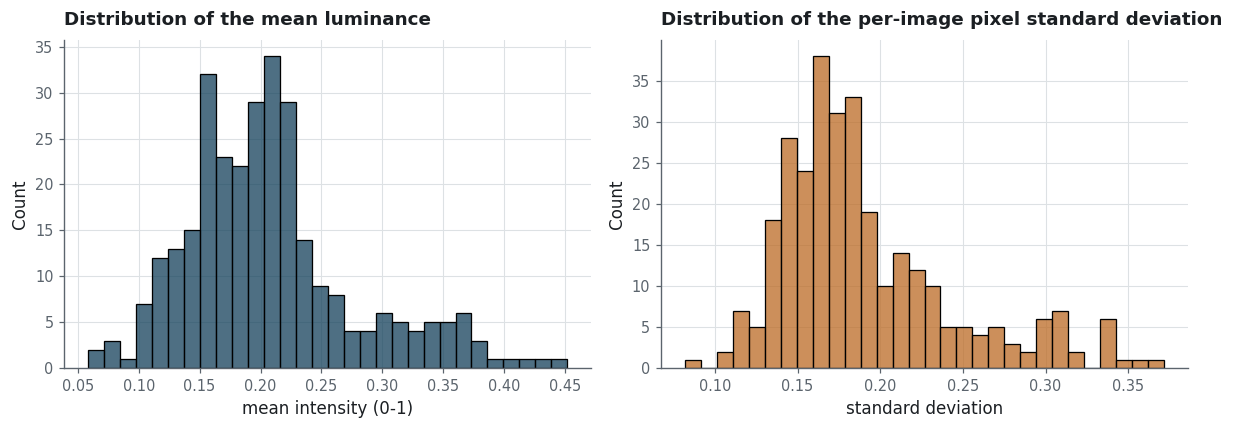

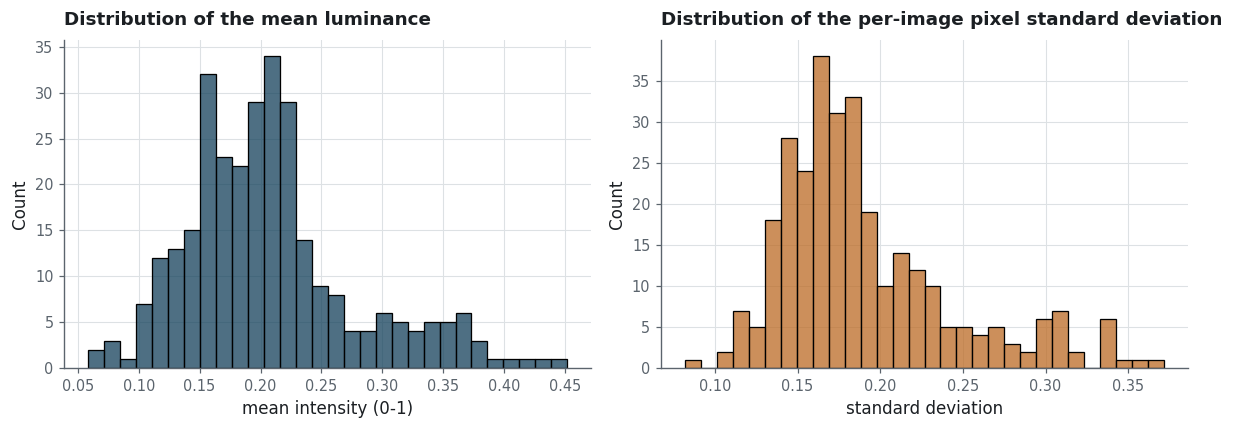

In [5]:
from mri_semisupervised.data.loader import compute_pixel_stats, discover_images
from mri_semisupervised.viz.plots import plot_pixel_stats

records, corrupted = discover_images()
print(f"{len(records)} readable files, {len(corrupted)} unreadable")

stats = compute_pixel_stats(records, sample_size=300, seed=0)
plot_pixel_stats(stats)

In [6]:
by_class = stats.merge(
    manifest[["image_id", "label"]].drop_duplicates("image_id"), on="image_id", how="left"
)
by_class["label"] = by_class["label"].fillna("unlabelled")
by_class.groupby("label")[["mean", "std"]].describe().round(1).T

label       cancer  normal  unlabelled
mean count    11.0    19.0       270.0
     mean      0.2     0.3         0.2
     std       0.1     0.1         0.1
     min       0.1     0.1         0.1
     25%       0.1     0.2         0.2
     50%       0.2     0.3         0.2
     75%       0.2     0.3         0.2
     max       0.3     0.5         0.4
std  count    11.0    19.0       270.0
     mean      0.2     0.2         0.2
     std       0.1     0.1         0.1
     min       0.1     0.1         0.1
     25%       0.1     0.2         0.2
     50%       0.2     0.2         0.2
     75%       0.2     0.3         0.2
     max       0.3     0.3         0.4

The labelled classes sit a few grey levels apart on the mean, and the unlabelled pool covers
both. That gap is small, and notebook 04 shows what happens to the clustering when histogram
equalisation removes it.